# Classic Text Classification Model

In this notebook, we build a classical NLP model to classify customer support tweets by company.

The model uses:
- TF-IDF for text representation
- Logistic Regression for classification

we use a train/validation/test split.  
The validation set is used for model optimisation, while the test set is only used for final evaluation.

In [1]:
# Import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Import evaluation metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
# Load the cleaned dataset created in data exploaration notebook
df = pd.read_csv("../Data/final_tweets.csv")

# Show dataset size
print("Dataset shape:", df.shape)

# Preview the dataset
df.head()

Dataset shape: (59184, 4)


,tweet_id,text,clean_text,company
0,277379,Another great set of @Delta flights thank to #...,another great set of flights thank to tmobilew...,delta
1,2488664,@AppleSupport why is my iPhone automatically g...,why is my iphone automatically going on mute,applesupport
2,2383194,@Uber_Support Since yesterday I haven't receiv...,since yesterday i havent received any update a...,uber_support
3,1610886,"@AmazonHelp There is no email from 2 days, jus...",there is no email from days just asked to wait...,amazonhelp
4,2763258,"@SouthwestAir thanks for responding, will call...",thanks for responding will call as soon as i g...,southwestair


The dataset contains the cleaned tweets and their company labels.  
The `clean_text` column is used as the input text, while the `company` column is used as the target label.

In [ ]:
# Check missing values
df[["clean_text", "company"]].isnull().sum()

clean_text    0
company       0
dtype: int64

In [4]:
# Count how many tweets belong to each company
company_counts = df["company"].value_counts()

print(company_counts)

company
amazonhelp      15663
applesupport    10827
americanair      5996
delta            5349
uber_support     5266
southwestair     4274
virgintrains     4208
tesco            3846
spotifycares     3755
Name: count, dtype: int64


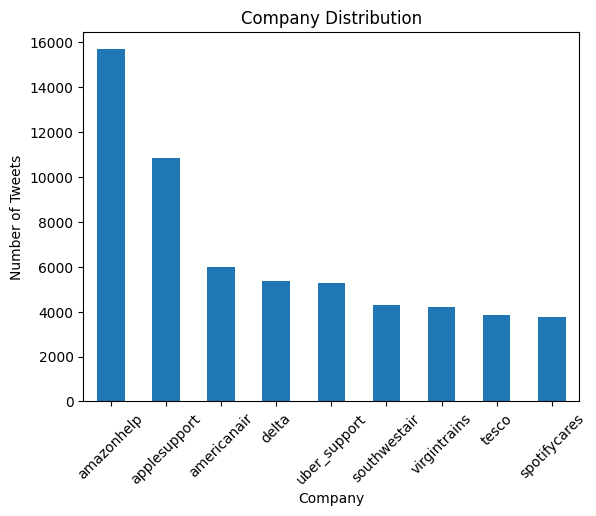

In [5]:
# Plot company distribution
company_counts.plot(kind="bar")

plt.title("Company Distribution")
plt.xlabel("Company")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.show()

The company distribution is not perfectly balanced.  
Because of this, we will use macro F1-score in addition to accuracy.

Accuracy shows the overall percentage of correct predictions, while macro F1 gives equal importance to each company class.

## Train, Validation, and Test Split

To evaluate the model properly, we split the dataset into three parts:

- Training set: used to train the model
- Validation set: used to compare hyperparameter
- Test set: used only for final evaluation

In [6]:
# First split: 70% training and 30% temporary data
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["company"]
)

# Second split: split temporary data into 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["company"]
)

# Print split sizes
print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (41428, 4)
Validation set shape: (8878, 4)
Test set shape: (8878, 4)


In [7]:
# Check whether the class distribution is similar in each split
print("Training distribution:")
print(train_df["company"].value_counts(normalize=True).round(3))

print("\nValidation distribution:")
print(val_df["company"].value_counts(normalize=True).round(3))

print("\nTest distribution:")
print(test_df["company"].value_counts(normalize=True).round(3))

Training distribution:
company
amazonhelp      0.265
applesupport    0.183
americanair     0.101
delta           0.090
uber_support    0.089
southwestair    0.072
virgintrains    0.071
tesco           0.065
spotifycares    0.063
Name: proportion, dtype: float64

Validation distribution:
company
amazonhelp      0.265
applesupport    0.183
americanair     0.101
delta           0.090
uber_support    0.089
southwestair    0.072
virgintrains    0.071
tesco           0.065
spotifycares    0.063
Name: proportion, dtype: float64

Test distribution:
company
amazonhelp      0.265
applesupport    0.183
americanair     0.101
delta           0.090
uber_support    0.089
southwestair    0.072
virgintrains    0.071
tesco           0.065
spotifycares    0.064
Name: proportion, dtype: float64


In [8]:
# Define input text and labels for each split
X_train = train_df["clean_text"]
y_train = train_df["company"]

X_val = val_df["clean_text"]
y_val = val_df["company"]

X_test = test_df["clean_text"]
y_test = test_df["company"]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 41428
Validation samples: 8878
Test samples: 8878


## Baseline Model: TF-IDF + Logistic Regression

As a first classical NLP model, we use TF-IDF features with Logistic Regression.

This baseline gives us a simple starting point before hyperparameter tuning.  
Later, we will compare tuned models against this baseline to show whether optimisation improves performance.

In [12]:
# Create a baseline TF-IDF + Logistic Regression pipeline
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train the model on the training set
baseline_model.fit(X_train, y_train)

print("Baseline model training completed.")

Baseline model training completed.


In [13]:
# Predict company labels for the validation set
y_val_pred = baseline_model.predict(X_val)

# Calculate validation metrics
baseline_accuracy = accuracy_score(y_val, y_val_pred)
baseline_macro_f1 = f1_score(y_val, y_val_pred, average="macro")
baseline_weighted_f1 = f1_score(y_val, y_val_pred, average="weighted")

print("Baseline Validation Accuracy:", round(baseline_accuracy, 4))
print("Baseline Validation Macro F1:", round(baseline_macro_f1, 4))
print("Baseline Validation Weighted F1:", round(baseline_weighted_f1, 4))

Baseline Validation Accuracy: 0.6636
Baseline Validation Macro F1: 0.6171
Baseline Validation Weighted F1: 0.6534


In [14]:
# Show detailed performance for each company
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

  amazonhelp       0.64      0.88      0.74      2350
 americanair       0.54      0.53      0.53       900
applesupport       0.74      0.81      0.78      1624
       delta       0.54      0.39      0.45       802
southwestair       0.55      0.41      0.47       641
spotifycares       0.76      0.52      0.61       563
       tesco       0.74      0.55      0.63       577
uber_support       0.70      0.58      0.63       790
virgintrains       0.81      0.62      0.70       631

    accuracy                           0.66      8878
   macro avg       0.67      0.59      0.62      8878
weighted avg       0.66      0.66      0.65      8878



The baseline TF-IDF + Logistic Regression model achieved 66% accuracy and a macro F1-score of 0.62 on the validation set. The model performed better on larger and more distinctive classes such as Amazon Help and Apple Support, while performance was weaker for some airline-related companies. This suggests that several classes share similar vocabulary, making the classification more difficult.

## Hyperparameter Tuning

The baseline model used one fixed set of parameters.  
To improve the model more we test different TF-IDF and Logistic Regression settings.

We tune:
- `max_features`: maximum number of TF-IDF features
- `ngram_range`: whether to use single words or single words + bigrams
- `C`: regularization strength for Logistic Regression
- `class_weight`: whether to adjust for class imbalance

The best model is selected based on validation macro F1-score.

In [15]:
# Import product
from itertools import product

# Define parameters for tuning
max_features_options = [5000, 10000]
ngram_range_options = [(1, 1), (1, 2)]
C_options = [0.1, 1, 10]
class_weight_options = [None, "balanced"]

# Store results from each experiment
tuning_results = []

# Try every combination of parameters
for max_features, ngram_range, C, class_weight in product(
    max_features_options,
    ngram_range_options,
    C_options,
    class_weight_options
):
    # Create model pipeline
    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range
        )),
        ("classifier", LogisticRegression(
            max_iter=1000,
            C=C,
            class_weight=class_weight
        ))
    ])
    
    # Train model on training data
    model.fit(X_train, y_train)
    
    # Predict on validation data
    y_val_pred = model.predict(X_val)
    
    # Calculate evaluation scores
    accuracy = accuracy_score(y_val, y_val_pred)
    macro_f1 = f1_score(y_val, y_val_pred, average="macro")
    weighted_f1 = f1_score(y_val, y_val_pred, average="weighted")
    
    # Save result
    tuning_results.append({
        "max_features": max_features,
        "ngram_range": ngram_range,
        "C": C,
        "class_weight": class_weight,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })
    
    # Print progress
    print(
        f"Done: max_features={max_features}, "
        f"ngram_range={ngram_range}, C={C}, "
        f"class_weight={class_weight}, macro_f1={round(macro_f1, 4)}"
    )

Done: max_features=5000, ngram_range=(1, 1), C=0.1, class_weight=None, macro_f1=0.5142
Done: max_features=5000, ngram_range=(1, 1), C=0.1, class_weight=balanced, macro_f1=0.5758
Done: max_features=5000, ngram_range=(1, 1), C=1, class_weight=None, macro_f1=0.6171
Done: max_features=5000, ngram_range=(1, 1), C=1, class_weight=balanced, macro_f1=0.6055
Done: max_features=5000, ngram_range=(1, 1), C=10, class_weight=None, macro_f1=0.6101
Done: max_features=5000, ngram_range=(1, 1), C=10, class_weight=balanced, macro_f1=0.5974
Done: max_features=5000, ngram_range=(1, 2), C=0.1, class_weight=None, macro_f1=0.4893
Done: max_features=5000, ngram_range=(1, 2), C=0.1, class_weight=balanced, macro_f1=0.5594
Done: max_features=5000, ngram_range=(1, 2), C=1, class_weight=None, macro_f1=0.5916
Done: max_features=5000, ngram_range=(1, 2), C=1, class_weight=balanced, macro_f1=0.577
Done: max_features=5000, ngram_range=(1, 2), C=10, class_weight=None, macro_f1=0.5789
Done: max_features=5000, ngram_rang

In [16]:
# Convert tuning results into a DataFrame
results_df = pd.DataFrame(tuning_results)

# Sort by macro F1-score
results_df = results_df.sort_values(by="macro_f1", ascending=False)

# Show best results
results_df.head(10)

,max_features,ngram_range,C,class_weight,accuracy,macro_f1,weighted_f1
14,10000,"(1, 1)",1.0,NaN,0.665127,0.620324,0.655062
2,5000,"(1, 1)",1.0,NaN,0.663550,0.617109,0.653352
16,10000,"(1, 1)",10.0,NaN,0.659833,0.614567,0.654474
4,5000,"(1, 1)",10.0,NaN,0.656679,0.610102,0.651447
15,10000,"(1, 1)",1.0,balanced,0.650710,0.609648,0.654100
3,5000,"(1, 1)",1.0,balanced,0.646993,0.605499,0.650733
20,10000,"(1, 2)",1.0,NaN,0.654427,0.605102,0.643480
17,10000,"(1, 1)",10.0,balanced,0.647443,0.604967,0.651389
22,10000,"(1, 2)",10.0,NaN,0.647556,0.600519,0.642878
21,10000,"(1, 2)",1.0,balanced,0.641811,0.598957,0.645213


In [19]:
# Save tuning results for the report
results_df.to_csv("../results/tables/classic_model_tuning_results.csv", index=False)

print("Tuning results saved successfully.")

Tuning results saved successfully.


## Tuning Result Discussion

The tuned model performed slightly better than the baseline. The improvement was small, with macro F1 increasing from 0.6171 to 0.6203. This suggests that increasing the TF-IDF vocabulary size from 5,000 to 10,000 features helped the model capture a few more useful terms, but the overall performance stayed similar.

Interestingly, adding bigrams did not improve performance. This may be because tweets are short and noisy, so single-word TF-IDF features already capture most of the useful signal.


Now we train the best model

In [20]:
# Join training and validation data for final training
train_val_df = pd.concat([train_df, val_df], axis=0)

# final training inputs and labels
X_train_val = train_val_df["clean_text"]
y_train_val = train_val_df["company"]

# Test data stays untouched until final evaluation
X_test = test_df["clean_text"]
y_test = test_df["company"]

print("Final training samples:", len(X_train_val))
print("Final test samples:", len(X_test))

Final training samples: 50306
Final test samples: 8878


In [21]:
# Create the best model based on validation tuning results
best_classic_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 1)
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight=None
    ))
])

# Train the final model using training + validation data
best_classic_model.fit(X_train_val, y_train_val)

print("Best classic model training completed.")

Best classic model training completed.


In [22]:
# Predict labels for the test set
y_test_pred = best_classic_model.predict(X_test)

# Calculate final test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")
test_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")

print("Final Test Accuracy:", round(test_accuracy, 4))
print("Final Test Macro F1:", round(test_macro_f1, 4))
print("Final Test Weighted F1:", round(test_weighted_f1, 4))

Final Test Accuracy: 0.6718
Final Test Macro F1: 0.6255
Final Test Weighted F1: 0.6623


Final Classification report

In [26]:
# Show detailed class-level performance
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

  amazonhelp       0.66      0.89      0.76      2349
 americanair       0.52      0.53      0.52       899
applesupport       0.75      0.81      0.78      1624
       delta       0.56      0.42      0.48       803
southwestair       0.56      0.41      0.48       641
spotifycares       0.75      0.51      0.61       564
       tesco       0.74      0.58      0.65       577
uber_support       0.73      0.59      0.65       790
virgintrains       0.79      0.65      0.72       631

    accuracy                           0.67      8878
   macro avg       0.67      0.60      0.63      8878
weighted avg       0.67      0.67      0.66      8878



In [24]:
# Save final model scores in a table
classic_final_results = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "max_features": 10000,
        "ngram_range": "(1, 1)",
        "C": 1.0,
        "class_weight": "None",
        "test_accuracy": test_accuracy,
        "test_macro_f1": test_macro_f1,
        "test_weighted_f1": test_weighted_f1
    }
])

# Save results for the final report
classic_final_results.to_csv("../results/tables/classic_model_final_results.csv", index=False)

classic_final_results

,model,max_features,ngram_range,C,class_weight,test_accuracy,test_macro_f1,test_weighted_f1
0,TF-IDF + Logistic Regression,10000,"(1, 1)",1.0,None,0.671773,0.625493,0.662322


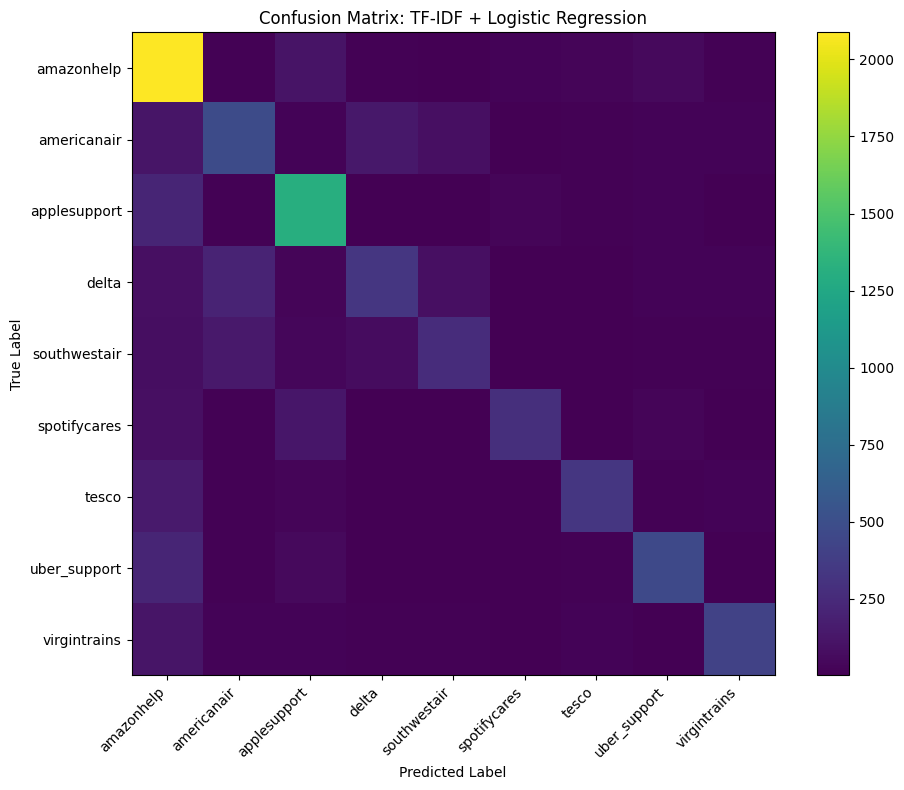

<Figure size 640x480 with 0 Axes>

In [27]:
#confusion matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix: TF-IDF + Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.colorbar()
plt.tight_layout()
plt.show()

# Save figure for the final report
plt.savefig("../results/figures/classic_model_confusion_matrix.png", dpi=300)


## Classic Model Results

The final TF-IDF + Logistic Regression model achieved 67% accuracy and a macro F1-score of 0.63 on the test set.

The model performed better on companies with more distinctive language patterns, such as Amazon Help and Apple Support.  
However, it struggled more with airline-related companies such as Delta, American Airlines, and Southwest Air. This is likely because customer complaints about airlines often use similar vocabulary, making the classes harder to separate.

Overall, the classic model provides a strong baseline for comparison with neural and prompting-based models.

## Notebook Summary

In this notebook, we implemented a classical text classification model using TF-IDF and Logistic Regression.

Main steps completed:
- Loaded the cleaned tweet dataset
- Created train, validation, and test splits
- Trained a baseline TF-IDF + Logistic Regression model
- Performed hyperparameter tuning using the validation set
- Selected the best model based on validation macro F1-score
- Evaluated the final model on the test set
- Saved final results and the confusion matrix

The final model achieved a test accuracy of 67% and a macro F1-score of 0.63.  
This model will be used as the classical baseline when comparing against neural and prompting-based models.